# 03 — Building the dictionary and firing the CAM

Notebook 02 turned a waveform into a *key*. This notebook builds the **rows** to compare it
against, fires the CAM for the first time, and looks at the distance distributions that the
entire detector is built on.

By the end you should be able to answer:

1. What is a codebook row, concretely — and why is it stored at 45°?
2. What does the CAM actually return, and what is it forbidden from returning?
3. Is the $\theta_0$ quadrant sweep an optimization, or is it load-bearing?
4. What do the four kinds of "cell" look like as distributions?
5. Why must $\tau$ be calibrated empirically instead of from the formula?

Modules: [`sim/gps/codebook.py`](../sim/gps/codebook.py), [`sim/cam.py`](../sim/cam.py),
[`sim/gps/experiments.py`](../sim/gps/experiments.py).
Theory companion: [`docs/gps_algorithm_explained.md`](../docs/gps_algorithm_explained.md) §5–6.

In [1]:
import sys, pathlib, math, inspect
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from sim.cam import CAM
from sim.gps import channel, codebook, quantize
from sim.gps.prn import CODE_LENGTH
from sim.gps.experiments import GpsConfig, build, dwell_keys, fire_counts, segment_distances

plt.rcParams.update({"figure.figsize": (9, 3), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

FS, T = 2.046e6, 1e-3
NS = int(round(FS * T))

---
## 1. What a row actually is

A row is a **noiseless replica taken to full scale**, then mapped through the same key
mapping as a live sample. One row per (PRN, Doppler) hypothesis.

Full scale matters: because a row only ever holds the extreme levels, a thermometer row is
`000` or `111` — one bit of information per rail — which is why the thermometer mapping
widens the match line without widening the memory (notebook 02 §4).

In [2]:
cb = codebook.build_codebook(prns=[1, 2, 3], f_max=10e3, t_coh=T, fs=FS, mapping="sign")
print(f"rows          : {cb.rows.shape}  (N rows x W bits)")
print(f"N = {cb.N} = {len(set(cb.prn_of_row))} PRNs x {len(cb.fd_grid)} Doppler bins")
print(f"W = {cb.W} bits = {NS} samples x 2 rails x 1 bit")
print()
print("first 5 rows, tagged:")
for i in range(5):
    print(f"  row {i:3d}: PRN {cb.prn_of_row[i]}, fd = {cb.fd_of_row[i]:+8.1f} Hz, "
          f"bits {cb.rows[i][:12].astype(int)} ...")
print()
print(f"rows for PRN 2: indices {cb.rows_for(2)[:4]} ... ({len(cb.rows_for(2))} of them)")

rows          : (123, 4092)  (N rows x W bits)
N = 123 = 3 PRNs x 41 Doppler bins
W = 4092 bits = 2046 samples x 2 rails x 1 bit

first 5 rows, tagged:
  row   0: PRN 1, fd = -10000.0 Hz, bits [1 1 1 1 1 1 1 1 1 1 0 0] ...
  row   1: PRN 1, fd =  -9500.0 Hz, bits [1 1 1 1 1 1 1 1 1 1 0 0] ...
  row   2: PRN 1, fd =  -9000.0 Hz, bits [1 1 1 1 1 1 1 1 1 1 0 0] ...
  row   3: PRN 1, fd =  -8500.0 Hz, bits [1 1 1 1 1 1 1 1 1 1 0 0] ...
  row   4: PRN 1, fd =  -8000.0 Hz, bits [1 1 1 1 1 1 1 1 1 1 0 0] ...

rows for PRN 2: indices [41 42 43 44] ... (41 of them)


In [3]:
# A row is exactly: quantize the noiseless replica at full scale.
rep = channel.replica(prn=1, fd=0.0, fs=FS, n_samples=NS, theta=codebook.ROW_THETA)
by_hand = quantize.full_scale_key(rep, "sign").astype(bool)
row0 = cb.rows[int(np.flatnonzero((cb.prn_of_row == 1) & (cb.fd_of_row == 0.0))[0])]
print("row rebuilt by hand == stored row:", np.array_equal(by_hand, row0))
print(f"\nROW_THETA = {np.degrees(codebook.ROW_THETA):.0f} degrees")

row rebuilt by hand == stored row: True

ROW_THETA = 45 degrees


---
## 2. The 45° trap — the bug the sanity gates caught

The obvious choice is to store rows at $\theta = 0$. That is wrong, and the failure is quiet:
everything still runs, the numbers are just worse.

At $\theta_k = 0$ the replica $c \cdot e^{j0}$ is **purely real**, so the row's Q rail is a
constant. Half the match line then contributes variance with no signal.

In [4]:
for deg in [0, 45]:
    r_ = channel.replica(1, 0.0, FS, 512, theta=np.radians(deg))
    k_ = quantize.full_scale_key(r_, "sign").reshape(-1, 2)
    print(f"rows at {deg:2d} deg -> I rail takes values {np.unique(k_[:, 0])}, "
          f"Q rail takes values {np.unique(k_[:, 1])}"
          + ("   <-- Q RAIL IS DEAD" if len(np.unique(k_[:, 1])) == 1 else "   <-- both rails live"))

rows at  0 deg -> I rail takes values [0 1], Q rail takes values [0]   <-- Q RAIL IS DEAD
rows at 45 deg -> I rail takes values [0 1], Q rail takes values [0 1]   <-- both rails live


### Measure the damage

The **margin** is how far the aligned distance sits below the wrong-cell distribution, in
units of that distribution's standard deviation. Theory ([the boxed formula in
`docs/gps_algorithm_explained.md`](../docs/gps_algorithm_explained.md) §5):

$$ \frac{\Delta}{\sigma_d} = \sqrt{2\,(C/N_0)\,T}\;\cdot\;\sqrt{2/\pi}\;\cdot\;\cos\theta_e $$

We measure at *matched phase with a single comparison* — no quadrant sweep — because that is
the configuration the formula describes. (Section 4 shows why the real detector cannot be
measured this way.)

In [5]:
def margin(row_theta, sig_theta, cn0, trials=400, seed=11):
    # Matched-phase margin against a fixed row. No quadrant sweep: this is the
    # configuration the analytic formula describes.
    row = quantize.full_scale_key(channel.replica(1, 0.0, FS, NS, theta=row_theta), "sign").astype(bool)
    rng = np.random.default_rng(seed)
    A = channel.amplitude_for_cn0(cn0, FS)
    rep1 = channel.replica(1, 0.0, FS, NS, code_phase_chips=0.0, theta=0.0)
    rep0 = channel.replica(1, 0.0, FS, NS, code_phase_chips=CODE_LENGTH // 2, theta=0.0)
    def dist(rep):
        w = rng.normal(0, 1, (trials, NS)) + 1j * rng.normal(0, 1, (trials, NS))
        k = quantize.quantize_to_key(A * np.exp(1j * sig_theta) * rep[None, :] + w, 1.0, "sign")
        return (k.astype(bool) != row).sum(1)
    d1, d0 = dist(rep1), dist(rep0)
    return (d0.mean() - d1.mean()) / d0.std()

theory = lambda cn0, te=0.0: math.sqrt(2 * 10 ** (cn0 / 10) * T) * math.sqrt(2 / math.pi) * math.cos(te)

print(f"{'C/N0':>6} {'theory':>8} | {'rows@45':>9} {'ratio':>6} | {'rows@0':>8} {'ratio':>6}")
for cn0 in [45, 42, 38]:
    th, m45, m0 = theory(cn0), margin(codebook.ROW_THETA, codebook.ROW_THETA, cn0), margin(0.0, 0.0, cn0)
    print(f"{cn0:>6} {th:>8.2f} | {m45:>9.2f} {m45/th:>6.2f} | {m0:>8.2f} {m0/th:>6.2f}")

  C/N0   theory |   rows@45  ratio |   rows@0  ratio
    45     6.35 |      5.74   0.90 |     4.13   0.65
    42     4.49 |      4.05   0.90 |     2.85   0.64
    38     2.83 |      2.54   0.90 |     1.77   0.62


Rows at 45° track theory to within ~10% (the repo's gate
[`tests/gps/test_margin.py`](../tests/gps/test_margin.py) accepts 0.85–1.10). Rows at 0° come
in at a **constant ~0.63×** across every C/N0.

> **That constancy is the tell.** Noise makes ratios wander; a deterministic modelling error
> makes them sit still. Whenever a measured/predicted ratio is stable but wrong across an
> entire sweep, look for a bug, not for bad luck. This is how the trap was found.

0.63× in margin is about 4 dB of C/N0 thrown away by one line of codebook construction.

---
## 3. Firing the CAM

[`sim/cam.py`](../sim/cam.py) is the only module in the repo permitted to compare a key
against rows, and its contract is strict: **it returns booleans and nothing else.** No
distance, no rank, no argmin. That constraint is the whole research question — it is what a
real analog match line can actually give you in one cycle.

In [6]:
names = [n for n, _ in inspect.getmembers(CAM, inspect.isfunction) if not n.startswith("__")]
print("public methods :", [n for n in names if not n.startswith("_")])
print("private        :", [n for n in names if n.startswith("_")], "(a vectorized query, same semantics)")
print()
cam = CAM(cb.rows)
# For now we CHEAT: fix theta0 to the row phase, so no quadrant sweep is needed.
# Section 4 removes the cheat and shows what it was hiding.
sig = channel.generate(1, 45, 0.0, FS, NS, theta0=codebook.ROW_THETA,
                       code_phase_chips=0.0, rng=np.random.default_rng(0))
key = quantize.quantize_to_key(sig.samples, 1.0, "sign")

m = cam.query(key, tau=1900)
print(f"query returns : {type(m).__name__} of dtype {m.dtype}, shape {m.shape}")
print(f"rows fired    : {np.flatnonzero(m)}  ({m.sum()} of {cb.N})")
print()
print("Notice what we did NOT get back: any indication of HOW close each row was.")

public methods : ['query']
private        : ['_query_batch'] (a vectorized query, same semantics)

query returns : ndarray of dtype bool, shape (123,)
rows fired    : [20]  (1 of 123)

Notice what we did NOT get back: any indication of HOW close each row was.


### $\tau$ is the only knob

The match vector is a *threshold* applied to a distance we never see. Sweeping $\tau$ walks
from "nothing fires" to "everything fires"; the useful region is the narrow band in between
where the aligned row fires alone.

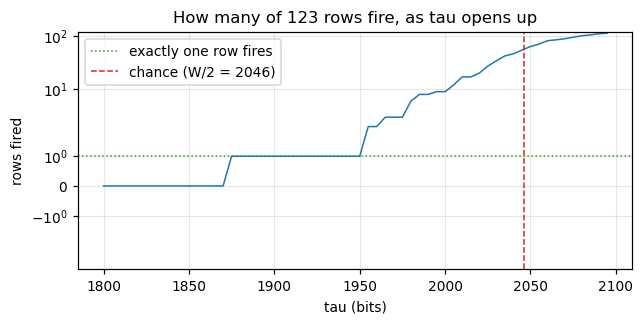

tau = 1840 ->   0 rows fire
tau = 1860 ->   0 rows fire
tau = 1900 ->   1 rows fire   [(1, 0.0)]
tau = 1980 ->   6 rows fire
tau = 2046 ->  56 rows fire


In [7]:
taus = np.arange(1800, 2100, 5)
n_fired = [cam.query(key, tau=t).sum() for t in taus]

fig, ax = plt.subplots(figsize=(6.5, 2.8))
ax.plot(taus, n_fired, lw=1)
ax.axhline(1, color="C2", ls=":", lw=1, label="exactly one row fires")
ax.axvline(cb.W // 2, color="C3", ls="--", lw=1, label=f"chance (W/2 = {cb.W//2})")
ax.set(xlabel="tau (bits)", ylabel="rows fired", yscale="symlog",
       title=f"How many of {cb.N} rows fire, as tau opens up")
ax.legend(); plt.show()

for t in [1840, 1860, 1900, 1980, 2046]:
    f = cam.query(key, tau=t)
    print(f"tau = {t:4d} -> {f.sum():3d} rows fire" +
          (f"   {[(cb.prn_of_row[i], cb.fd_of_row[i]) for i in np.flatnonzero(f)]}" if 0 < f.sum() <= 3 else ""))

### Why do so many rows fire once $\tau$ opens up?

The count goes 1 → 6 → 56 over a span of ~150 bits, which looks alarming. It is worth
understanding exactly what those extra rows are, because the answer is **not** "similar
hypotheses" — it is much more boring than that, and the boring answer is the useful one.

Every row that is not the aligned one sits at **chance**, wherever it came from. So the whole
dictionary is one big pile at $W/2$, with a single row pulled out to the left.

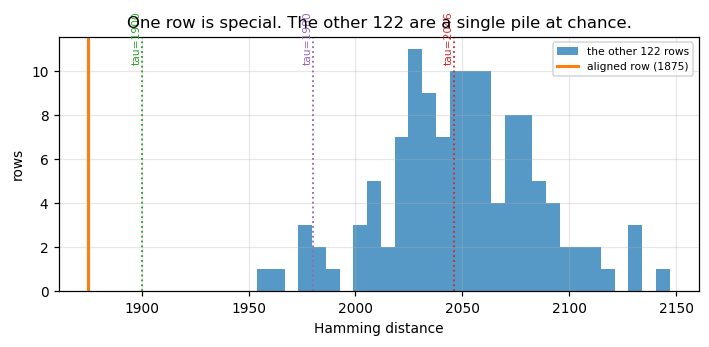

aligned row : 1875  (171 bits below chance)
other rows  : mean 2050.3, std 35.7   (analytic: mean 2046, std 32.0)


In [8]:
d_all = (cb.rows != key.astype(bool)).sum(1)          # characterization only, not the detector
correct = int(np.flatnonzero((cb.prn_of_row == 1) & (cb.fd_of_row == 0.0))[0])
wrong_d = np.delete(d_all, correct)

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.hist(wrong_d, bins=30, alpha=0.75, label=f"the other {len(wrong_d)} rows")
ax.axvline(d_all[correct], color="C1", lw=2, label=f"aligned row ({d_all[correct]})")
for t, col in [(1900, "C2"), (1980, "C4"), (2046, "C3")]:
    ax.axvline(t, color=col, ls=":", lw=1.2)
    ax.annotate(f"tau={t}", (t, ax.get_ylim()[1] * 0.9), rotation=90, fontsize=7,
                ha="right", color=col)
ax.set(xlabel="Hamming distance", ylabel="rows",
       title="One row is special. The other 122 are a single pile at chance.")
ax.legend(fontsize=7); plt.show()

print(f"aligned row : {d_all[correct]}  ({2046 - d_all[correct]} bits below chance)")
print(f"other rows  : mean {wrong_d.mean():.1f}, std {wrong_d.std():.1f}"
      f"   (analytic: mean {cb.W/2:.0f}, std {np.sqrt(cb.W)/2:.1f})")

So "how many rows fire at $\tau$" is just **how far into that pile $\tau$ has reached** — a
Gaussian tail count, nothing structural:

$$ \text{rows fired} \;\approx\; N_{\text{wrong}} \cdot \Phi\!\left(\frac{\tau - \mu_0}{\sigma_0}\right) $$

In [9]:
from scipy.stats import norm
mu0, sd0 = wrong_d.mean(), wrong_d.std()
print(f"{'tau':>6} {'observed':>9} {'predicted':>10}")
for t in [1900, 1950, 1980, 2000, 2020, 2046, 2060]:
    print(f"{t:>6} {int((wrong_d <= t).sum()):>9d} {len(wrong_d)*norm.cdf((t-mu0)/sd0):>10.1f}")
print("\nAt tau = 2046 you are thresholding at the MEAN of the pile, so ~half of it fires.")
print("The avalanche is not a failure mode -- it is what asking a threshold to sit at chance means.")

   tau  observed  predicted
  1900         0        0.0
  1950         0        0.3
  1980         5        3.0
  2000         8        9.7
  2020        19       24.2
  2046        55       55.1
  2060        80       74.0

At tau = 2046 you are thresholding at the MEAN of the pile, so ~half of it fires.
The avalanche is not a failure mode -- it is what asking a threshold to sit at chance means.


The design consequence: the usable window for $\tau$ is the gap between the aligned row and
the left edge of that pile — here about $(2050 - 1875)/36 \approx 4.9\sigma$ wide, and it
*shrinks as C/N0 drops*. At 38 dB-Hz the aligned row is only ~90 bits below chance against a
pile with $\sigma \approx 32$, i.e. under $3\sigma$. Choosing $\tau$ inside a window that
narrow is exactly the sense-margin problem of notebook 06.

### A genuine surprise hiding in the same plot

Look again at which rows joined at $\tau = 1980$: PRN 2 and PRN 3 at scattered Dopplers.
**PRN 1's own neighbouring Doppler bins are absent** — even though notebook 01 showed a
$\pm500$ Hz mismatch retains $|\mathrm{sinc}(0.5)| = 0.637$ of the correlation. Why doesn't
the neighbour partially match?

Because a Doppler offset does not just shrink the correlation, it **rotates** it. The residual
ramp accumulates a mean phase of $\pi f_d T$:

In [10]:
r0 = channel.replica(1, 0.0, FS, NS, theta=0.0)
print(f"{'fd (Hz)':>8} {'|corr|':>8} {'phase':>9} {'Re part':>9}   {'predicted phase = 180*fd*T':>28}")
for fd in [0, 250, 500, 750, 1000]:
    z = np.vdot(channel.replica(1, fd, FS, NS, theta=0.0), r0) / NS
    print(f"{fd:>8} {abs(z):>8.3f} {np.degrees(np.angle(z)):>8.1f}d {z.real:>9.3f}   {-180*fd*T:>28.1f}")

 fd (Hz)   |corr|     phase   Re part     predicted phase = 180*fd*T
       0    1.000      0.0d     1.000                            0.0
     250    0.900    -45.0d     0.637                          -45.0
     500    0.637    -90.0d     0.000                          -90.0
     750    0.300   -134.9d    -0.212                         -135.0
    1000    0.000   -176.5d    -0.000                         -180.0


At $f_d = 500$ Hz the residual is rotated by exactly **90°** — it is entirely in *quadrature*.
A single fixed rotation projects onto the real axis and sees nothing, which is precisely why
the neighbour sat at chance above.

And that is a symptom of the cheat in this section, not of the design. Restore the quadrant
sweep and the quadrature energy is recovered:

In [11]:
cb1 = codebook.build_codebook(prns=[1], f_max=10e3, t_coh=T, fs=FS, mapping="sign")
print(f"{'fd (Hz)':>9} {'q=0 only':>10} {'min over 4':>12}   {'|sinc|':>8}")
for i in cb1.rows_for(1):
    fd = cb1.fd_of_row[i]
    if abs(fd) <= 1000:
        ds = [int((quantize.rotate_key(key, q, "sign").astype(bool) != cb1.rows[i]).sum())
              for q in range(4)]
        print(f"{fd:>9.0f} {ds[0]:>10d} {min(ds):>12d}   {abs(np.sinc(fd*T)):>8.3f}")

  fd (Hz)   q=0 only   min over 4     |sinc|
    -1000       2027         2027      0.000
     -500       2078         1990      0.637
        0       1875         1875      1.000
      500       2044         1932      0.637
     1000       2057         2019      0.000


The $+500$ Hz row goes from 2044 (chance) to **1932** once the sweep is allowed — a real
partial match, roughly where $\mathrm{sinc}(0.5) = 0.637$ says it should be.

> **So in the real detector, adjacent Doppler bins *do* fire — and that is by design.** The
> grid is spaced at $1/(2T)$ precisely so a true signal is never more than half a bin from a
> stored row. A small cluster of neighbouring fires is the signature of a *detection*, not a
> false alarm; the tracking loop is handed the bin index and refines from there. What must not
> happen is the pile at chance crossing $\tau$ — those are the false alarms the budget counts.

---
## 4. Is the $\theta_0$ sweep load-bearing? (yes, completely)

Notebook 02 showed the four rotations are *exact* and therefore free in hardware. But the
signal in section 3 had a **random** $\theta_0$, as any real signal does. What happens if we
only ever look at one rotation?

Below: same trials, same rows. Once using quadrant 0 alone, once taking the best of four.

In [12]:
row_ok = quantize.full_scale_key(channel.replica(1, 0.0, FS, NS, theta=codebook.ROW_THETA),
                                 "sign").astype(bool)

def collect(cn0, trials=400, seed=0):
    # Distances under H1 (aligned) and H0 (random wrong code phase), with theta0 random.
    rng = np.random.default_rng(seed)
    out = {k: [] for k in ("H1_q0", "H1_min", "H0_q0", "H0_min")}
    for _ in range(trials):
        for tag, cp in (("H1", 0.0), ("H0", float(rng.uniform(2, CODE_LENGTH - 2)))):
            s = channel.generate(1, cn0, 0.0, FS, NS, code_phase_chips=cp, rng=rng).samples
            k = quantize.quantize_to_key(s, 1.0, "sign")
            ds = [int((quantize.rotate_key(k, q, "sign").astype(bool) != row_ok).sum()) for q in range(4)]
            out[f"{tag}_q0"].append(ds[0]); out[f"{tag}_min"].append(min(ds))
    return {k: np.array(v) for k, v in out.items()}

for cn0 in [45, 38]:
    d = collect(cn0)
    for tag, lbl in (("q0", "one quadrant "), ("min", "best of four")):
        sep = d[f"H0_{tag}"].mean() - d[f"H1_{tag}"].mean()
        sd = d[f"H0_{tag}"].std()
        print(f"C/N0={cn0}  {lbl}: separation {sep:6.1f} bits, H0 std {sd:5.1f} -> margin {sep/sd:5.2f}")
    print()

C/N0=45  one quadrant : separation    4.1 bits, H0 std  31.2 -> margin  0.13
C/N0=45  best of four: separation  146.8 bits, H0 std  18.1 -> margin  8.12

C/N0=38  one quadrant : separation    1.5 bits, H0 std  31.1 -> margin  0.05
C/N0=38  best of four: separation   49.1 bits, H0 std  17.7 -> margin  2.78



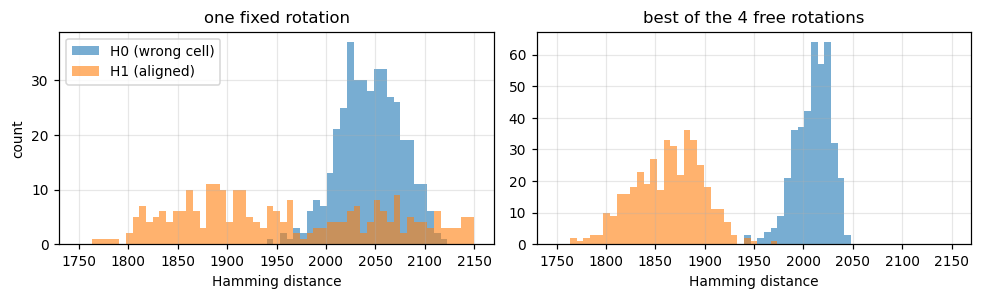

In [13]:
d45 = collect(45)
fig, axes = plt.subplots(1, 2, figsize=(9, 2.8), sharex=True)
bins = np.linspace(1750, 2150, 60)
for ax, tag, title in zip(axes, ["q0", "min"],
                          ["one fixed rotation", "best of the 4 free rotations"]):
    ax.hist(d45[f"H0_{tag}"], bins=bins, alpha=0.6, label="H0 (wrong cell)")
    ax.hist(d45[f"H1_{tag}"], bins=bins, alpha=0.6, label="H1 (aligned)")
    ax.set(title=f"{title}", xlabel="Hamming distance")
axes[0].set_ylabel("count"); axes[0].legend()
plt.tight_layout(); plt.show()

> ### The sweep is not an optimization — without it there is no detector
>
> With a single fixed rotation the margin is **0.05–0.12**: the two histograms sit on top of
> each other. $\theta_0$ is uniform on $[0, 2\pi)$, so a fixed rotation averages the
> correlation to zero. The receiver would never acquire anything, at any C/N0, for any $\tau$.
>
> With the sweep, the margin at 38 dB-Hz is **2.83** — which is exactly the value the boxed
> formula predicts. Free in hardware, and mandatory in fact.

There is a subtlety worth noticing in those histograms, because it drives the rest of the
study. Taking a minimum over four draws changes the H0 distribution: it pulls the floor down
(from $W/2 = 2046$ to about 2010) **and narrows it** (std 32 → 18).

In [14]:
print(f"H0, one quadrant : mean {d45['H0_q0'].mean():7.1f}  std {d45['H0_q0'].std():5.1f}"
      f"    <- theory: mean {cb.W/2:.0f}, std {np.sqrt(cb.W)/2:.1f}")
print(f"H0, min of four  : mean {d45['H0_min'].mean():7.1f}  std {d45['H0_min'].std():5.1f}"
      f"    <- no longer the analytic distribution")

H0, one quadrant : mean  2044.4  std  31.2    <- theory: mean 2046, std 32.0
H0, min of four  : mean  2009.5  std  18.1    <- no longer the analytic distribution


The single-rotation numbers land on the analytic $W/2$ and $\sqrt{W}/2$ almost exactly — the
model is right. But the *detector* does not use that distribution, it uses the min-of-four
one, and there is no tidy closed form for it.

**This is why $\tau$ is calibrated from measured distances rather than computed.** The repo
does exactly this in
[`experiments.segment_distances`](../sim/gps/experiments.py) — a characterization pass whose
only job is to look at distances so a threshold can be chosen. The detector itself still
consumes nothing but booleans.

---
## 5. The four kinds of cell

A cell can be wrong in three different ways, and they are not interchangeable. The detector
has to reject all three, so calibration must use whichever is *closest* — the hardest one.

| cell | what it is |
|---|---|
| `aligned` | right PRN, right Doppler, right code phase — this is $H_1$ |
| `wrong_phase` | right PRN and Doppler, wrong code phase (1022 of these per row) |
| `wrong_doppler` | right PRN and code phase, wrong Doppler bin |
| `wrong_prn` | a different satellite's row |

`segment_distances` measures all four in one pass.

In [15]:
cfg = GpsConfig(n_segments=1, n_prn=3)
d = segment_distances(cfg, cn0=45.0, trials=400, rng=np.random.default_rng(0))

print(f"{'cell':>14} {'mean':>8} {'std':>7}   {'below chance':>13}")
for k in ("aligned", "wrong_phase", "wrong_doppler", "wrong_prn"):
    v = d[k].ravel()
    print(f"{k:>14} {v.mean():8.1f} {v.std():7.1f}   {(0.5 - v.mean()/cb.W)*100:11.2f} %")

          cell     mean     std    below chance
       aligned   1860.0    33.6          4.55 %
   wrong_phase   2009.2    19.1          0.90 %
 wrong_doppler   2009.8    18.7          0.88 %
     wrong_prn   2011.4    18.6          0.85 %


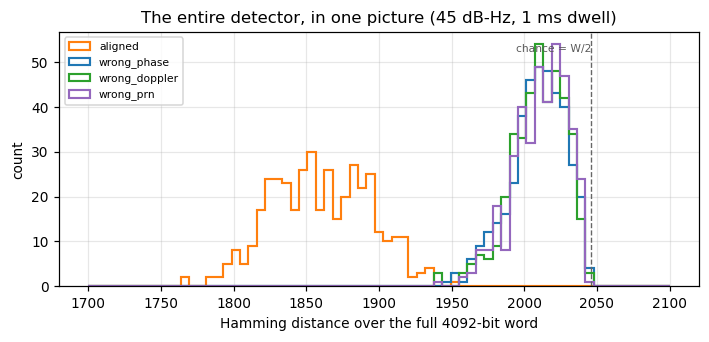

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 3))
bins = np.linspace(1700, 2100, 70)
for k, col in zip(("aligned", "wrong_phase", "wrong_doppler", "wrong_prn"),
                  ["C1", "C0", "C2", "C4"]):
    ax.hist(d[k].ravel(), bins=bins, histtype="step", lw=1.4, label=k, color=col)
ax.axvline(cb.W // 2, color="0.4", ls="--", lw=0.9)
ax.annotate("chance = W/2", (cb.W // 2, ax.get_ylim()[1] * 0.92), fontsize=7,
            ha="right", color="0.35")
ax.set(xlabel="Hamming distance over the full 4092-bit word", ylabel="count",
       title="The entire detector, in one picture (45 dB-Hz, 1 ms dwell)")
ax.legend(fontsize=7); plt.show()

The three wrong-cell distributions lie **on top of each other**. That is the Gold-code
property from notebook 01 restated in the bit domain: a wrong code phase, a wrong Doppler bin
and a wrong satellite are all simply *uncorrelated*, and uncorrelated is uncorrelated.

Convenient for design — one $H_0$ model covers all three — but it also means there is no
structural difference to exploit. The only separation available is the aligned distribution's
small shift to the left.

---
## 6. What $\tau$ buys: $p_1$ and $p_0$

Fix $\tau$ and two numbers follow: $p_1$ = P(aligned cell fires) and $p_0$ = P(a wrong cell
fires). Everything in notebooks 05–08 is computed from this pair.

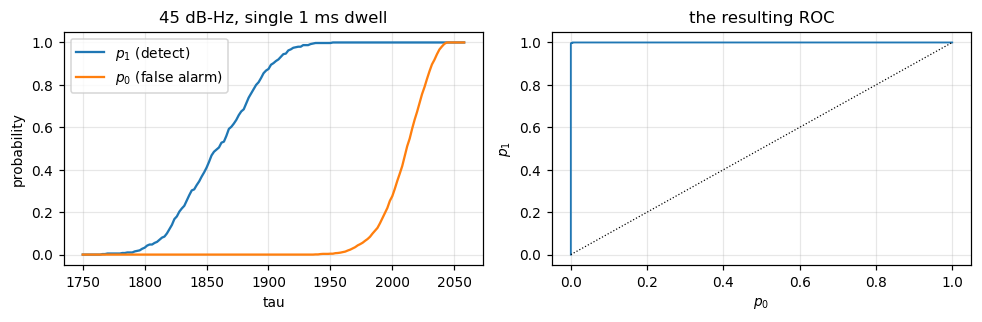

widest gap at tau = 1938: p1 = 0.998, p0 = 0.001


In [17]:
aligned = d["aligned"].ravel()
wrong = np.concatenate([d[k].ravel() for k in ("wrong_phase", "wrong_doppler", "wrong_prn")])

taus = np.arange(1750, 2060, 2)
p1 = np.array([(aligned <= t).mean() for t in taus])
p0 = np.array([(wrong <= t).mean() for t in taus])

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(taus, p1, label="$p_1$ (detect)")
axes[0].plot(taus, p0, label="$p_0$ (false alarm)")
axes[0].set(xlabel="tau", ylabel="probability", title="45 dB-Hz, single 1 ms dwell")
axes[0].legend()
axes[1].plot(p0, p1, lw=1.2)
axes[1].plot([0, 1], [0, 1], "k:", lw=0.8)
axes[1].set(xlabel="$p_0$", ylabel="$p_1$", title="the resulting ROC")
plt.tight_layout(); plt.show()

best = np.argmax(p1 - p0)
print(f"widest gap at tau = {taus[best]}: p1 = {p1[best]:.3f}, p0 = {p0[best]:.3f}")

### And now the wall

Notebook 01 computed the per-cell false-alarm budget for a 1% system Pfa over a 1.34 M-cell
search: **$7.5\times10^{-9}$**. Look at the $p_0$ we can even *measure* with 400 trials.

In [18]:
cells = CODE_LENGTH * len(cb.fd_grid) * 32
budget = 1e-2 / cells
print(f"per-cell budget           : {budget:.2e}")
print(f"smallest p0 measurable    : {1/len(wrong):.2e}   ({len(wrong)} wrong-cell samples)")
print(f"tau giving p0 = 0 in {len(wrong)} samples: {taus[p0 == 0].max() if (p0 == 0).any() else None}")
if (p0 == 0).any():
    t_star = taus[p0 == 0].max()
    print(f"   ...but at that tau, p1 = {p1[taus == t_star][0]:.3f}")

per-cell budget           : 7.45e-09
smallest p0 measurable    : 8.33e-04   (1200 wrong-cell samples)
tau giving p0 = 0 in 1200 samples: 1936
   ...but at that tau, p1 = 0.995


Two lessons, and they shape the whole evaluation strategy:

1. **You cannot Monte-Carlo a $10^{-9}$ probability.** It would take $\sim10^{11}$ trials.
   So the repo measures the *per-segment* rates $p_1, p_0$ — which are $O(0.1)$ and cheap to
   estimate — and then **combines them analytically** with a binomial model over $M$ dwells.
   That is notebook 07, and it is why `experiments.py` is written the way it is.
2. **A single dwell cannot close the gap.** At any $\tau$ tight enough to be safe, $p_1$
   collapses. This is notebook 01's punchline arriving from the other direction: acquisition
   *time* is the currency, and non-coherent accumulation over many dwells is mandatory —
   which, conveniently, is something a boolean readout does perfectly well.

---
## What we established

| Fact | Where it bites later |
|---|---|
| A row = full-scale replica at $\theta = 45°$, one per (PRN, Doppler) | dictionary size (nb 05) |
| Rows at 0° cost a constant 0.63× margin (~4 dB) | *constant* wrong ratios ⇒ bug, not noise |
| `CAM.query` returns booleans only; $\tau$ is the sole knob | the constraint the whole project tests |
| Without the quadrant sweep the margin is ~0.05 — no detector at all | the sweep is load-bearing, not an optimization |
| With it, margin at 38 dB-Hz = 2.83, matching the boxed formula | nb 04 validates this across C/N0 |
| min-of-4 breaks the analytic $H_0$ distribution (std 32 → 18) | **$\tau$ must be calibrated empirically** (nb 06) |
| All three wrong-cell types coincide | one $H_0$ model suffices |
| Per-cell budget $7.5{\times}10^{-9}$ is unmeasurable by MC | measure $p_1,p_0$, combine analytically (nb 07) |

## Next

**Notebook 04 — `margin.ipynb`.** We take the boxed formula seriously: verify
$\Delta/\sigma_d = \sqrt{2(C/N_0)T}\sqrt{2/\pi}\cos\theta_e$ term by term across C/N0 and
phase, confirm that oversampling does *not* appear in it (widening $W$ buys nothing), and turn
it into the gate that `tests/gps/test_margin.py` enforces.

### Try it yourself
- In §2, try rows at 22.5° and 67.5°. Is 45° actually optimal, or just better than 0°?
- In §5, re-run at 38 dB-Hz. How much of the aligned distribution's separation survives?
- In §3, what is the smallest $\tau$ at which the *correct* row still fires? Compare it to `W/2`.